# Geospatial Electoral Analysis

This notebook transforms election-level predictive data into a geographic coordinate pipeline to visualize electoral signal distributions, regional hierarchies, and prediction accuracy across global democracies.

### Workflow Architecture:
1. **Setup & Ingestion:**  Load feature-engineered.
2. **Wide-to-Long Transformation:**  Melt election rows into individual electorate geographic points.
3. **Coordinate Mapping & Cleaning:**  Standardize text and apply bulletproof latitude/longitude assignment.
4. **Interactive Folium Mapping (Vis 1–4):**  Build spatial layers for regional rank, accuracy, and signal strength.
5. **Plotly Analytics & Animation (Vis 5–6):**  Generate country comparisons and historical time-series animations.

In [184]:
import numpy as np
import pandas as pd
import folium
from folium.plugins import MarkerCluster, HeatMap
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [185]:
#load dataset
df = pd.read_csv(r"D:\Global-election-predictive-analysis\data\processed\Elections_Feature_Engineered.csv")

id_vars = [
    "Country",
    "country_type",
    "election_year",
    "national_winner",
    "prediction_correct",
    "agreement_score"
]

# Define hierarchical mapping weights
rank_mapping = {
    "largest_electorate": {"rank": 1, "signal": 1.00, "category": "High"},
    "second_electorate": {"rank": 2, "signal": 0.67, "category": "Medium"},
    "third_electorate": {"rank": 3, "signal": 0.33, "category": "Low"}
}

# Transform wide dataset to long format 
geo_df = df.melt(
    id_vars=id_vars,
    value_vars=list(rank_mapping.keys()),
    var_name="electorate_type",
    value_name="Region"
)

# Map hierarchical features
geo_df["Region_rank"] = geo_df["electorate_type"].map(lambda x: rank_mapping[x]["rank"])
geo_df["signal_strength"] = geo_df["electorate_type"].map(lambda x: rank_mapping[x]["signal"])
geo_df["signal_rank_category"] = geo_df["electorate_type"].map(lambda x: rank_mapping[x]["category"])


geo_df = geo_df.drop(columns=["electorate_type"]).sort_values(by=["Country", "election_year", "Region_rank"]).reset_index(drop=True)

print(f"Transformation complete. Total geographic points generated: {len(geo_df)}")
geo_df.head()

Transformation complete. Total geographic points generated: 171


,Country,country_type,election_year,national_winner,prediction_correct,agreement_score,Region,Region_rank,signal_strength,signal_rank_category
0,Brazil,Developing,1989,Fernando Collor,True,1.0,SÆo Paulo,1,1.00,High
1,Brazil,Developing,1989,Fernando Collor,True,1.0,Minas Gerais,2,0.67,Medium
2,Brazil,Developing,1989,Fernando Collor,True,1.0,Rio de Janeiro,3,0.33,Low
3,Brazil,Developing,1994,Fernando Henrique Cardoso,True,1.0,SÆo Paulo,1,1.00,High
4,Brazil,Developing,1994,Fernando Henrique Cardoso,True,1.0,Minas Gerais,2,0.67,Medium


In [186]:
geo_df["Region"] = (
    geo_df["Region"]
    .astype(str)
    .str.strip()
    .str.replace("\xa0", "", regex=False)
    .replace({
        "SÆo Paulo": "São Paulo",
        "Set£bal": "Setúbal"
    })
)


coordinates = {
    "Homagama": (6.8447, 80.0030),
    "Kaduwela": (6.9344, 79.9847),
    "Kesbewa": (6.8014, 79.9220),
    "California": (36.7783, -119.4179),
    "Texas": (31.9686, -99.9018),
    "Florida": (27.6648, -81.5158),
    "São Paulo": (-23.5505, -46.6333),
    "Minas Gerais": (-19.9167, -43.9345),
    "Rio de Janeiro": (-22.9068, -43.1729),
    "West Java": (-6.9175, 107.6191),
    "East Java": (-7.2504, 112.7688),
    "Central Java": (-7.1500, 110.1403),
    "Lisboa": (38.7223, -9.1393),
    "Porto": (41.1579, -8.6291),
    "Setúbal": (38.5244, -8.8882),
    "Gyeonggi": (37.4138, 127.5183),
    "Seoul": (37.5665, 126.9780),
    "Busan": (35.1796, 129.0756)
}


geo_df["latitude"] = geo_df["Region"].map(lambda x: coordinates.get(x, (np.nan, np.nan))[0])
geo_df["longitude"] = geo_df["Region"].map(lambda x: coordinates.get(x, (np.nan, np.nan))[1])

##Bulletproof Fallback 
sk_mask = geo_df["Region"].str.contains("Gyeonggi", case=False, na=False)
geo_df.loc[sk_mask, "latitude"] = 37.4138
geo_df.loc[sk_mask, "longitude"] = 127.5183

## Zero-NaN Verification
missing_coords = geo_df[geo_df["latitude"].isna() | geo_df["longitude"].isna()]
print(f"Missing coordinate rows remaining: {len(missing_coords)}")
assert len(missing_coords) == 0, "Error: Unmapped coordinates detected!"

Missing coordinate rows remaining: 0


### Visualization 1 (Global Cluster Map)

In [187]:
# Map
map_vis1 = folium.Map(location=[15.0, 10.0], zoom_start=2, tiles="CartoDB positron")
cluster = MarkerCluster().add_to(map_vis1)

# Populate markers
for _, row in geo_df.drop_duplicates(subset=["Country", "Region"]).iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=f"<b>{row['Region']}</b> ({row['Country']})<br>Type: {row['country_type']}",
        tooltip=f"{row['Region']} - Rank {row['Region_rank']}",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(cluster)

map_vis1

## Visualization 2: Top 3 Electoral Regions Interactive Map
Differentiates regions by their electoral importance using color-coded markers:
* **Rank 1 (Largest):** Red
* **Rank 2 (Second):** Orange
* **Rank 3 (Third):** Green

In [188]:
map_vis2 = folium.Map(location=[15.0, 10.0], zoom_start=2, tiles="CartoDB positron")

rank_colors = {1: "red", 2: "orange", 3: "green"}

for _, row in geo_df.drop_duplicates(subset=["Country", "Region"]).iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=14 - (row["Region_rank"] * 3),  # Rank 1 = larger radius
        color=rank_colors[row["Region_rank"]],
        fill=True,
        fill_color=rank_colors[row["Region_rank"]],
        fill_opacity=0.7,
        popup=f"<b>{row['Region']}</b><br>Rank: {row['Region_rank']}<br>Signal Strength: {row['signal_strength']}"
    ).add_to(map_vis2)

map_vis2

## Visualization 3 - Country-Level Predictive Accuracy Comparison

This interactive comparison chart aggregates metrics at the national level to evaluate predictive accuracy rates and agreement scores across **Developed** and **Developing** democracies. It highlights systemic differences in predictive performance across geopolitical regimes.

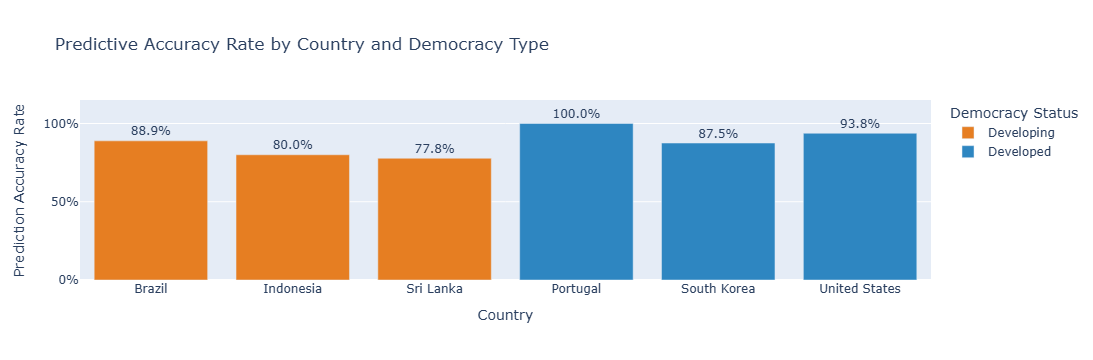

In [174]:
# Aggregate metrics # Aggregate metrics at the country level
country_summary = geo_df.groupby(["Country", "country_type"]).agg(
    accuracy_rate=("prediction_correct", "mean"),
    avg_agreement=("agreement_score", "mean"),
    total_elections=("election_year", "nunique")
).reset_index()


fig_vis5 = px.bar(
    country_summary,
    x="Country",
    y="accuracy_rate",
    color="country_type",
    text="accuracy_rate",
    title="Predictive Accuracy Rate by Country and Democracy Type",
    labels={"accuracy_rate": "Prediction Accuracy Rate", "country_type": "Democracy Status"},
    color_discrete_map={"Developed": "#2E86C1", "Developing": "#E67E22"},
    range_y=[0, 1.15]  
)

fig_vis5.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig_vis5.update_layout(yaxis_tickformat=".0%")
fig_vis5.show()country_summary = geo_df.groupby(["Country", "country_type"]).agg(
    accuracy_rate=("prediction_correct", "mean"),
    avg_agreement=("agreement_score", "mean"),
    total_elections=("election_year", "nunique")
).reset_index()

# Plot interactive comparison bar chart
fig_vis5 = px.bar(
    country_summary,
    x="Country",
    y="accuracy_rate",
    color="country_type",
    text="accuracy_rate",
    title="Predictive Accuracy Rate by Country and Democracy Type",
    labels={"accuracy_rate": "Prediction Accuracy Rate", "country_type": "Democracy Status"},
    color_discrete_map={"Developed": "#2E86C1", "Developing": "#E67E22"}
)

fig_vis5.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig_vis5.update_layout(yaxis_tickformat=".0%", ylim=[0, 1.15])
fig_vis5.show()

## Visualization 4 - Electoral Signal Flow Diagram

This parallel categories diagram maps the structural pathways between geopolitical regime types, electorate signal hierarchies, and predictive success rates. By tracing categorical connections across dimensions, this visualization reveals whether specific signal ranks (e.g., Low vs. High) create predictive bottlenecks within Developing or Developed democracies.

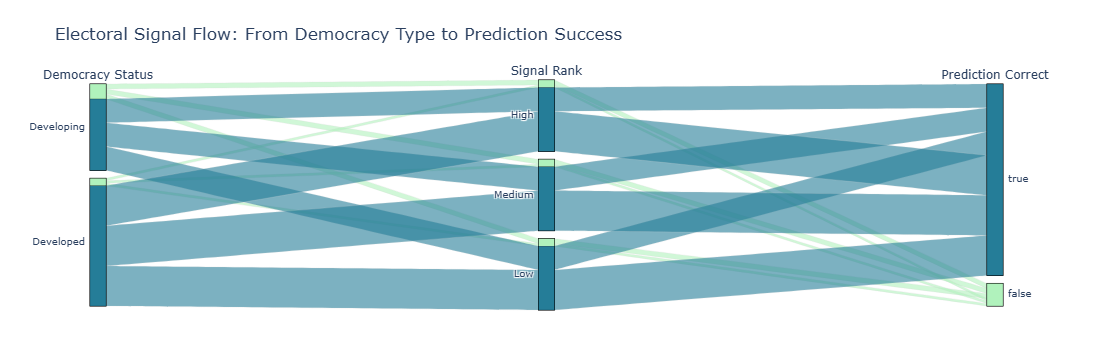

In [182]:

geo_df["accuracy_int"] = geo_df["prediction_correct"].astype(int)

# Generate parallel categories 
fig_flow = px.parallel_categories(
    geo_df,
    dimensions=["country_type", "signal_rank_category", "prediction_correct"],
    color="accuracy_int",
    color_continuous_scale=px.colors.sequential.Tealgrn,
    labels={
        "country_type": "Democracy Status",
        "signal_rank_category": "Signal Rank",
        "prediction_correct": "Prediction Correct",
        "accuracy_int": "Accuracy Scale"
    },
    title="Electoral Signal Flow: From Democracy Type to Prediction Success"
)


fig_flow.update_layout(
    margin=dict(l=50, r=50, t=80, b=50),
    coloraxis_showscale=False  # Hide colorbar as boolean values are self-explanatory
)

fig_flow.show()

##### Visualization 5 - Historical Electoral Agreement Score Matrix

This longitudinal heatmap evaluates systemic stability over time by pivoting historical election cycles against tracked nations. Plotting the mean agreement score as a continuous color matrix allows quantitative researchers to instantly identify chronological periods of political volatility, regime shifts, or predictive model divergence across global democracies.

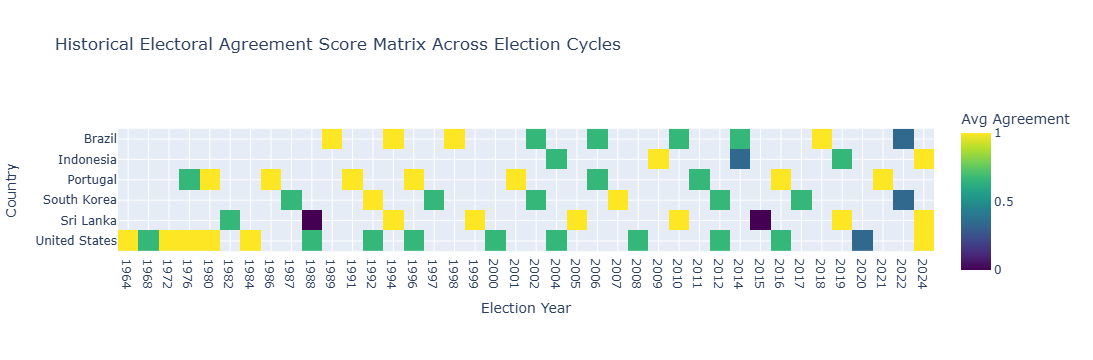

In [190]:
# Create pivot table from current data
pivot_data = geo_df.pivot_table(
    index="Country", 
    columns="election_year", 
    values="agreement_score", 
    aggfunc="mean"
)

fig_heatmap = px.imshow(
    pivot_data,
    labels=dict(x="Election Year", y="Country", color="Avg Agreement"),
    x=pivot_data.columns,
    y=pivot_data.index,
    color_continuous_scale="Viridis",
    title="Historical Electoral Agreement Score Matrix Across Election Cycles"
)
fig_heatmap.update_xaxes(type='category')
fig_heatmap.show()